# Анализ результатов экспериментов

Сравнение трех подходов генерации эвристик для задач планирования:
- **DSL** - полное DSL-описание -> `solve_scheduling(jobs, resources)`
- **Text** - текстовый промпт -> `solve_scheduling(jobs, resources)`  
- **Skeleton** - краткое DSL -> `select_job_fn + allocate_fn` через каркас SSGS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 1. Загрузка данных

In [2]:
# Укажите пути к файлам
DSL_FILE = '../../results/dsl/schedule_results.xlsx'
TEXT_FILE = '../../results/text/schedule_results.xlsx'
SKELETON_FILE = '../../results/skeleton/heuristics_schedule_results.xlsx'

df_dsl = pd.read_excel(DSL_FILE)
df_text = pd.read_excel(TEXT_FILE)
df_skel = pd.read_excel(SKELETON_FILE)

print(f"DSL: {len(df_dsl)} строк, колонки: {list(df_dsl.columns)}")
print(f"Text: {len(df_text)} строк, колонки: {list(df_text.columns)}")
print(f"Skeleton: {len(df_skel)} строк, колонки: {list(df_skel.columns)}")

DSL: 50 строк, колонки: ['Папка', 'Кейс', 'Run', 'Метод', 'Статус', 'Makespan', 'Penalty', 'Ошибка']
Text: 50 строк, колонки: ['Папка', 'Кейс', 'Run', 'Метод', 'Статус', 'Makespan', 'Penalty', 'Ошибка']
Skeleton: 50 строк, колонки: ['Case', 'Run', 'Метод', 'Статус', 'Primary Objective', 'Total Makespan', 'Iterations', 'Final Time', 'Schedule Size', 'Project Finish Times', 'Error']


## 2. Нормализация данных

In [3]:
CASE_NAMES = {
    'Case1_DSL_results':  'Case 1 (RCPSP)',
    'Case2_DSL_results':  'Case 2 (Single Machine)',
    'Case3_DSL_results':  'Case 3 (RCPSP+NRR)',
    'Case4_DSL_results':  'Case 4 (Conditional RCPSP)',
    'Case5_DSL_results':  'Case 5 (RCMPSP)',
    'Case1_text_results': 'Case 1 (RCPSP)',
    'Case2_text_results': 'Case 2 (Single Machine)',
    'Case3_text_results': 'Case 3 (RCPSP+NRR)',
    'Case4_text_results': 'Case 4 (Conditional RCPSP)',
    'Case5_text_results': 'Case 5 (RCMPSP)',
    1: 'Case 1 (RCPSP)',
    2: 'Case 2 (Single Machine)',
    3: 'Case 3 (RCPSP+NRR)',
    4: 'Case 4 (Conditional RCPSP)',
    5: 'Case 5 (RCMPSP)',
}

colors = {'DSL': '#4C72B0', 'Text': '#DD8452', 'Skeleton': '#55A868'}

# Нижние границы (CPL) для каждого кейса
LOWER_BOUNDS = {
    'Case 1 (RCPSP)': 38,               # CPL = оптимум, подтвержден в данных
    'Case 3 (RCPSP+NRR)': 106,          # CPL без учета ресурсов
    'Case 4 (Conditional RCPSP)': 110,  # CPL без учета ресурсов
    'Case 5 (RCMPSP)': 88,              # CPL обоих проектов = 88
}

def prepare_dsl_text(df, approach):
    out = pd.DataFrame()
    out['Подход'] = [approach] * len(df)
    out['Кейс'] = df['Кейс'].map(CASE_NAMES)
    out['Run'] = df['Run']
    out['Метод'] = df['Метод']
    out['Статус'] = df['Статус']
    out['Objective'] = df['Makespan'].combine_first(df['Penalty'])
    out['Ошибка'] = df['Ошибка']
    return out

def prepare_skeleton(df):
    out = pd.DataFrame()
    out['Подход'] = ['Skeleton'] * len(df)
    out['Кейс'] = df['Case'].map(CASE_NAMES)
    out['Run'] = df['Run']
    out['Метод'] = df['Метод']
    out['Статус'] = df['Статус']
    out['Objective'] = df['Primary Objective']
    out['Ошибка'] = df['Error']
    return out

dsl  = prepare_dsl_text(df_dsl, 'DSL')
text = prepare_dsl_text(df_text, 'Text')
skel = prepare_skeleton(df_skel)

df_all = pd.concat([dsl, text, skel], ignore_index=True)
df_all['Статус'] = df_all['Статус'].str.strip()
df_all['Статус_OK'] = df_all['Статус'] == 'OK'

print("Итого строк:", len(df_all))
print("Подходы:", df_all['Подход'].unique())
df_all.head(10)

Итого строк: 150
Подходы: ['DSL' 'Text' 'Skeleton']


,Подход,Кейс,Run,Метод,Статус,Objective,Ошибка,Статус_OK
0,DSL,Case 1 (RCPSP),1,Event-driven Serial Schedule Generation Scheme...,OK,NaN,NaN,True
1,DSL,Case 1 (RCPSP),2,Priority List Scheduling with Criticality (Bot...,runtime_error,NaN,"Traceback (most recent call last):\n File ""C:...",False
2,DSL,Case 1 (RCPSP),3,SSGS + Priority rule (Resource Pressure First)...,OK,65.0,NaN,True
3,DSL,Case 1 (RCPSP),4,Priority List Scheduling (Criticality-based) +...,OK,52.0,NaN,True
4,DSL,Case 1 (RCPSP),5,SSGS + критичность (минимальный slack) + earli...,OK,49.0,NaN,True
5,DSL,Case 1 (RCPSP),6,Priority List Scheduling with Criticality (Lon...,OK,52.0,NaN,True
6,DSL,Case 1 (RCPSP),7,SGS + приоритет по критичности (длины до стока...,OK,46.0,NaN,True
7,DSL,Case 1 (RCPSP),8,Greedy event-based RCPSP list scheduling with ...,OK,52.0,NaN,True
8,DSL,Case 1 (RCPSP),9,SSGS + приоритет по критичности (remaining lon...,OK,46.0,NaN,True
9,DSL,Case 1 (RCPSP),10,Serial SGS + priority (min slack / criticality...,OK,40.0,NaN,True


## 3. Надежность генерации

Процент успешных запусков (статус `OK`) по подходам и кейсам

In [4]:
reliability = df_all.groupby(['Подход', 'Кейс'])['Статус_OK'].agg(['sum','count'])
reliability.columns = ['OK', 'Total']
reliability['%'] = (reliability['OK'] / reliability['Total'] * 100).round(1)
reliability = reliability.reset_index()

# Сводная по подходам
total_rel = df_all.groupby('Подход')['Статус_OK'].agg(['sum','count'])
total_rel.columns = ['OK', 'Total']
total_rel['%'] = (total_rel['OK'] / total_rel['Total'] * 100).round(1)
print("Надежность по подходам:")
total_rel

Надежность по подходам:


,OK,Total,%
Подход,,,
DSL,43,50,86.0
Skeleton,48,50,96.0
Text,42,50,84.0


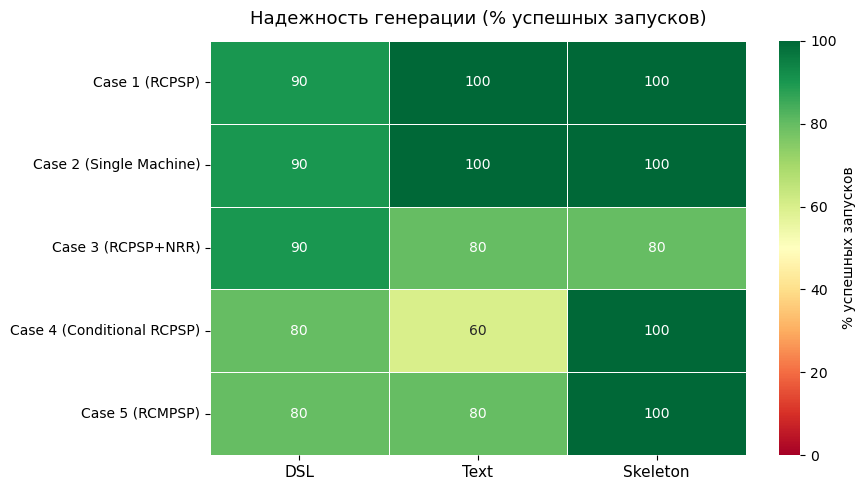

In [5]:
# Heatmap надежности
pivot = reliability.pivot(index='Кейс', columns='Подход', values='%')
pivot = pivot[['DSL', 'Text', 'Skeleton']]

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', vmin=0, vmax=100,
            linewidths=0.5, ax=ax, cbar_kws={'label': '% успешных запусков'})
ax.set_title('Надежность генерации (% успешных запусков)', fontsize=13, pad=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(fontsize=11)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plt.show()

Skeleton показывает наилучшую надежность для Cases 1, 2, 4 и 5 (100%), и наравне с DSL для Case 3 (80%). DSL стабилен во всех кейсах (80–90%) без резких провалов. Text наиболее нестабилен для Case 4 (60%) — задача с conditional scheduling оказалась наиболее сложной для текстового описания. Улучшение Skeleton для Case 4 (60% у Text -> 100% у Skeleton) наглядно демонстрирует преимущество каркасного подхода именно для сложных постановок с условными ограничениями.

## 4. Анализ ошибок

In [6]:
df_err = df_all[df_all['Статус'] != 'OK'].copy()

err_types = df_err.groupby(['Подход', 'Статус']).size().unstack(fill_value=0)
print("Распределение типов ошибок")
err_types

Распределение типов ошибок


Статус,runtime_error,skipped_generation_error,timeout
Подход,,,
DSL,4,0,3
Skeleton,0,2,0
Text,7,0,1


runtime_error - код скомпилировался, но упал при выполнении (KeyError, ValueError и т.д.)

skipped_generation_error - запуск был пропущен, потому что на этапе генерации LLM вернула ошибку (невалидный JSON)

timeout - бесконечный цикл, который принудительно закончили через 30 секунд

In [7]:
# Примеры ошибок по кейсам
df_err_sample = df_err[df_err['Ошибка'].notna()][['Подход','Кейс','Run','Статус','Ошибка']].copy()
df_err_sample['Краткая ошибка'] = df_err_sample['Ошибка'].str.split('\n').str[-2].str.strip()
df_err_sample[['Подход','Кейс','Run','Статус','Краткая ошибка']]

,Подход,Кейс,Run,Статус,Краткая ошибка
1,DSL,Case 1 (RCPSP),2,runtime_error,OverflowError: cannot convert float infinity t...
14,DSL,Case 2 (Single Machine),5,runtime_error,
25,DSL,Case 3 (RCPSP+NRR),6,runtime_error,
32,DSL,Case 4 (Conditional RCPSP),3,timeout,NaN
35,DSL,Case 4 (Conditional RCPSP),6,runtime_error,
43,DSL,Case 5 (RCMPSP),4,timeout,NaN
49,DSL,Case 5 (RCMPSP),10,timeout,NaN
70,Text,Case 3 (RCPSP+NRR),1,runtime_error,
76,Text,Case 3 (RCPSP+NRR),7,runtime_error,
80,Text,Case 4 (Conditional RCPSP),1,runtime_error,


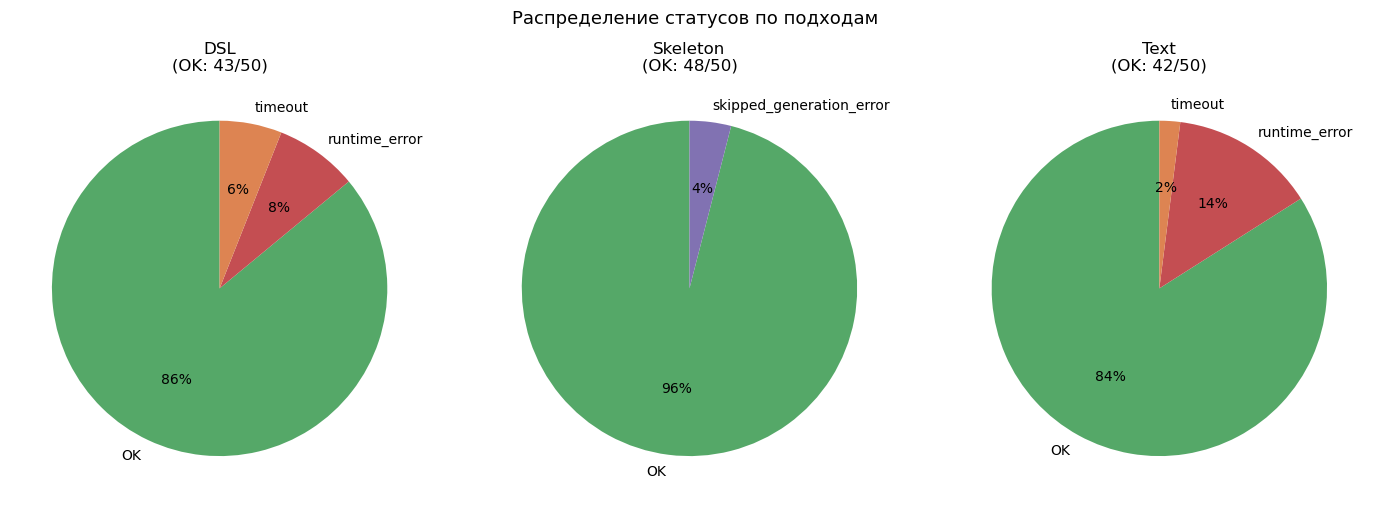

In [8]:
status_counts_full = df_all.groupby(['Подход', 'Статус']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
status_colors = {'OK': '#55A868', 'runtime_error': '#C44E52',
                 'timeout': '#DD8452', 'skipped_generation_error': '#8172B2'}

for ax, (approach, row) in zip(axes, status_counts_full.iterrows()):
    row_nz = row[row > 0]
    wedge_colors = [status_colors.get(s, '#999') for s in row_nz.index]
    ax.pie(row_nz, labels=row_nz.index, autopct='%1.0f%%',
           colors=wedge_colors, startangle=90)
    total = row.sum()
    ok = row.get('OK', 0)
    ax.set_title(f'{approach}\n(OK: {ok}/{total})')

plt.suptitle('Распределение статусов по подходам', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Skeleton показывает наилучшую надежность 96% - единственный тип ошибок это skipped_generation_error, то есть 2 запуска где LLM не смогла сгенерировать валидный JSON. DSL и Text сопоставимы (86% и 84%), но с разным профилем ошибок.

У DSL основные проблемы с runtime_error для Cases 1–3 и timeout для Cases 4–5. Timeout для Cases 4 и 5 указывает на то что сгенерированный код застревает в бесконечном цикле при работе с conditional scheduling и многопроектной структурой. 

У Text большинство ошибок сосредоточено в Cases 3–5 (наиболее сложных постановках). Пустые значения в колонке "Краткая ошибка" для timeout-строк объясняются тем что процесс был принудительно завершен без вывода.

## 5. Качество решений (значение целевой функции)

Анализ только для успешных запусков (`статус == OK`) с валидным значением objective (> 0)

In [9]:
df_ok = df_all[(df_all['Статус'] == 'OK') & 
               (df_all['Objective'].notna()) & 
               (df_all['Objective'] > 0)].copy()

obj_stats = df_ok.groupby(['Кейс', 'Подход'])['Objective'].agg(
    Count='count', Min='min', Mean='mean', Median='median', Max='max', Std='std').round(1)
obj_stats

Count      Min     Mean   Median  \
Кейс                       Подход                                       
Case 1 (RCPSP)             DSL           8     40.0     50.2     50.5   
                           Skeleton     10     38.0     38.0     38.0   
                           Text         10     43.0     60.3     46.5   
Case 2 (Single Machine)    DSL           9    549.0  23042.3  21806.0   
                           Skeleton     10  56710.0  83566.5  93762.0   
                           Text          9  18017.0  25400.1  20118.0   
Case 3 (RCPSP+NRR)         DSL           3     10.0     63.3     74.0   
                           Skeleton      8     23.0     24.2     24.0   
                           Text          3     65.0     74.7     70.0   
Case 4 (Conditional RCPSP) DSL           7      1.0     80.3    110.0   
                           Skeleton     10      9.0     15.2     16.0   
                           Text          3      6.0     48.7     26.0   
Case 5 (RCMPSP)            DSL           3     88.0     88.0     88.0   
                           Skeleton     10     88.0     88.0     88.0   
                           Text          8     33.0     83.0     88.0   

                                         Max      Std  
Кейс                       Подход                      
Case 1 (RCPSP)             DSL          65.0      7.3  
                           Skeleton     38.0      0.0  
                           Text        158.0     35.4  
Case 2 (Single Machine)    DSL       60530.0  18185.4  
                           Skeleton  93762.0  16494.1  
                           Text      54966.0  12417.1  
Case 3 (RCPSP+NRR)         DSL         106.0     48.9  
                           Skeleton     26.0      1.0  
                           Text         89.0     12.7  
Case 4 (Conditional RCPSP) DSL         136.0     54.8  
                           Skeleton     19.0      3.2  
                           Text        114.0     57.5  
Case 5 (RCMPSP)            DSL          88.0      0.0  
                           Skeleton     88.0      0.0  
                           Text        103.0     20.9

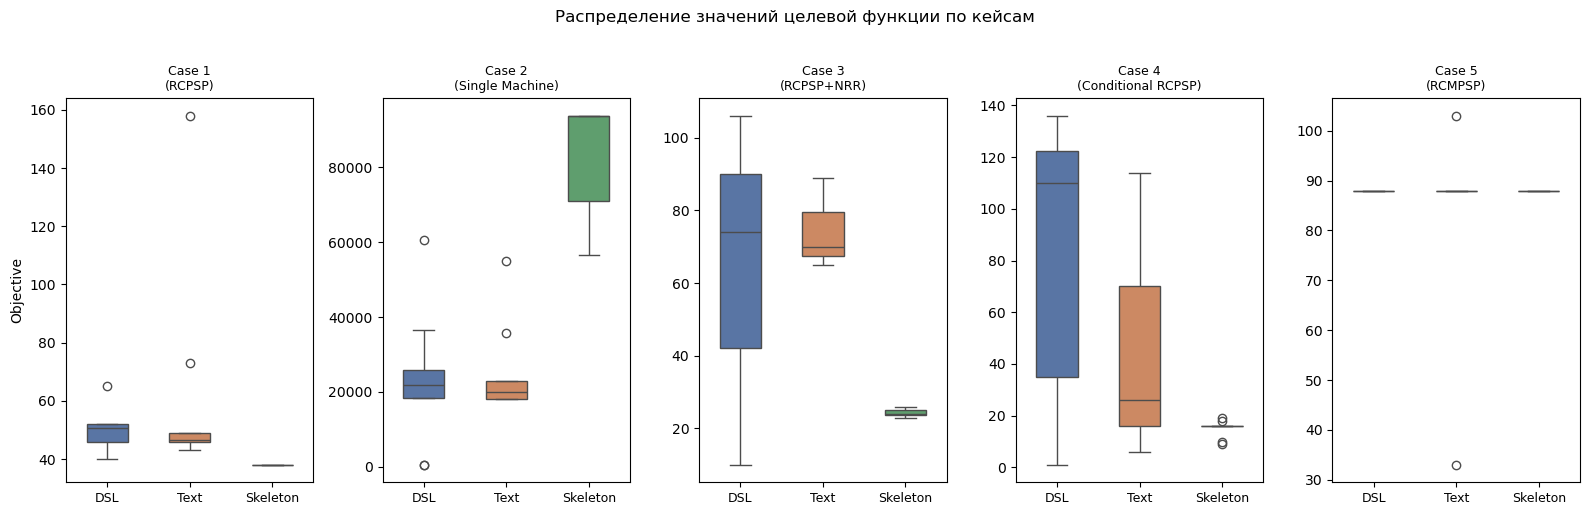

In [10]:
cases = df_ok['Кейс'].unique()
fig, axes = plt.subplots(1, len(cases), figsize=(16, 5), sharey=False)

for ax, case in zip(axes, sorted(cases)):
    data = df_ok[df_ok['Кейс'] == case]
    sns.boxplot(data=data, x='Подход', y='Objective', order=['DSL','Text','Skeleton'],
                palette=colors, ax=ax, width=0.5)
    ax.set_title(case.replace(' (', '\n('), fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('Objective' if ax == axes[0] else '')
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle('Распределение значений целевой функции по кейсам', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Skeleton превосходит DSL и Text по качеству решений одновременно обеспечивая наименьший разброс.

## 6. Детальный анализ по кейсам

### Case 1 Базовый RCPSP (makespan)

Целевая метрика: минимизация makespan.

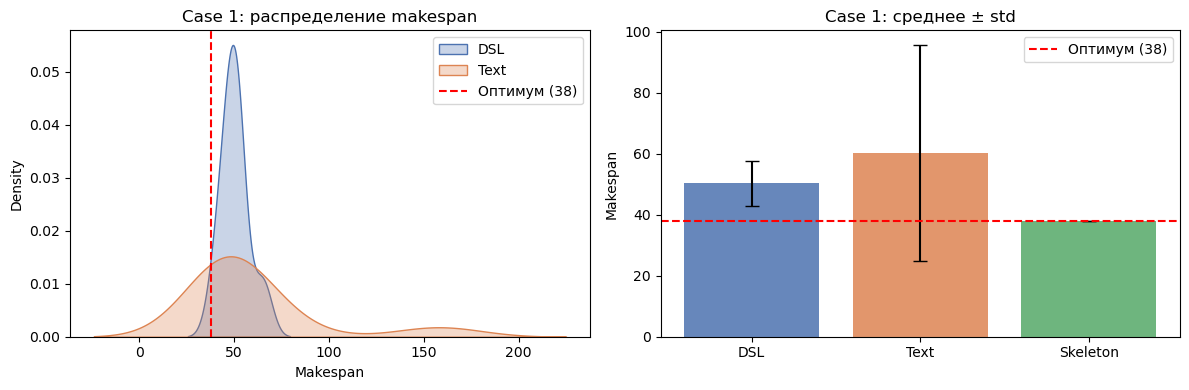

,count,mean,std,min,25%,50%,75%,max
Подход,,,,,,,,
DSL,8.0,50.2,7.3,40.0,46.0,50.5,52.0,65.0
Skeleton,10.0,38.0,0.0,38.0,38.0,38.0,38.0,38.0
Text,10.0,60.3,35.4,43.0,46.0,46.5,49.0,158.0


In [11]:
case = 'Case 1 (RCPSP)'
d1 = df_ok[df_ok['Кейс'] == case]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# KDE распределение
for подход, grp in d1.groupby('Подход'):
    if len(grp) > 1:
        sns.kdeplot(grp['Objective'], ax=ax1, label=подход, color=colors[подход], fill=True, alpha=0.3)
ax1.axvline(LOWER_BOUNDS[case], color='red', linestyle='--', label=f'Оптимум ({LOWER_BOUNDS[case]})')
ax1.set_title('Case 1: распределение makespan')
ax1.set_xlabel('Makespan')
ax1.legend()

stats1 = d1.groupby('Подход')['Objective'].agg(['mean','std']).reindex(['DSL','Text','Skeleton'])
ax2.bar(stats1.index, stats1['mean'], yerr=stats1['std'], capsize=5,
        color=[colors[p] for p in stats1.index], alpha=0.85)
ax2.axhline(LOWER_BOUNDS[case], color='red', linestyle='--', label=f'Оптимум ({LOWER_BOUNDS[case]})')
ax2.set_title('Case 1: среднее ± std')
ax2.set_ylabel('Makespan')
ax2.legend()
plt.tight_layout()
plt.show()

d1.groupby('Подход')['Objective'].describe().round(1)

Skeleton достигает оптимума makespan=38 во всех 10 запусках (Std=0). Это единственный подход, стабильно находящий оптимальное решение. DSL находит минимум 40 при среднем 50.2 и разбросе 7.3, то есть часть запусков близка к оптимуму, но стабильности нет. Text показывает наихудший результат: среднее 60.3, стандартное отклонение 35.4 и выброс до 158.

### Case 2 Single Machine / JIT

Целевая метрика: минимизация суммарного штрафа.

V-shape нижняя оценка оптимума: 92760
Значения в данных: [549.0, 549.0, 18017.0, 18021.0, 18184.0, 18292.0, 18644.0, 19552.0, 20118.0, 21806.0, 22000.0, 22908.0, 23657.0, 25840.0, 35743.0, 36606.0, 54966.0, 56710.0, 59199.0, 60530.0, 63422.0, 93762.0, 93762.0, 93762.0, 93762.0, 93762.0, 93762.0, 93762.0]



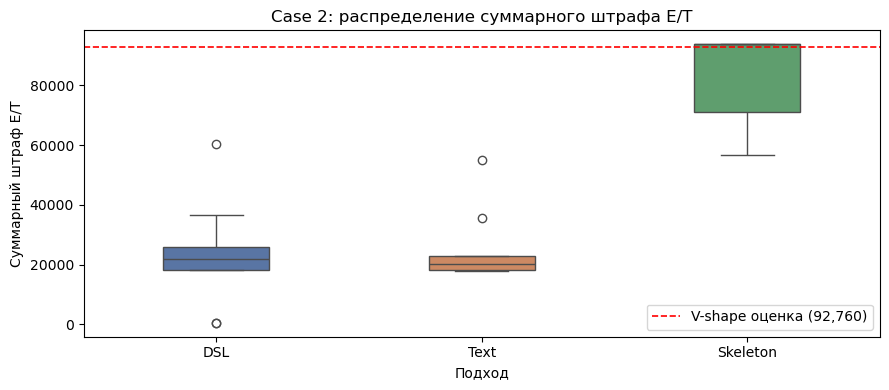

,count,mean,std,min,25%,50%,75%,max
Подход,,,,,,,,
DSL,9.0,23042.3,18185.4,549.0,18292.0,21806.0,25840.0,60530.0
Skeleton,10.0,83566.5,16494.1,56710.0,71007.0,93762.0,93762.0,93762.0
Text,9.0,25400.1,12417.1,18017.0,18184.0,20118.0,22908.0,54966.0


In [12]:
case = 'Case 2 (Single Machine)'
d2 = df_ok[df_ok['Кейс'] == case]

# Примечание: V-shape эвристика дает оценку 92 760
# Значения < 10 000 (напр. 4 663) — артефакты неверного вычисления метрики
V_SHAPE_LB = 92760
print(f"V-shape нижняя оценка оптимума: {V_SHAPE_LB}")
print(f"Значения в данных: {sorted(d2['Objective'].tolist())}")
print()

fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=d2, x='Подход', y='Objective', order=['DSL','Text','Skeleton'],
            palette=colors, width=0.4, ax=ax)
ax.axhline(V_SHAPE_LB, color='red', linestyle='--', linewidth=1.2,
           label=f'V-shape оценка ({V_SHAPE_LB:,})')
ax.set_title('Case 2: распределение суммарного штрафа E/T')
ax.set_ylabel('Суммарный штраф E/T')
ax.legend()
plt.tight_layout()
plt.show()

d2.groupby('Подход')['Objective'].describe().round(1)

Case 2 является наиболее проблемным кейсом для всех трех подходов. V-shape эвристика (как baseline) дает нижнюю оценку оптимума 92 760, но DSL и Text возвращают значения в диапазоне от 549 до 60530 и от 18017 до 54 966 соответственно, что значительно ниже физически возможного минимума. Это свидетельствует о том что сгенерированный код вычисляет метрику некорректно.

Skeleton же возвращает значения от 56710 до 93762, большинство из которых близки к V-shape оценке. Это указывает на то что каркас корректно вычисляет целевую функцию, а разброс объясняется различными стратегиями упорядочения работ. Таким образом, для Case 2 Skeleton является единственным подходом с физически достоверными результатами.

### Case 3 RCPSP с невозобновляемыми ресурсами

Целевая метрика: минимизация makespan.

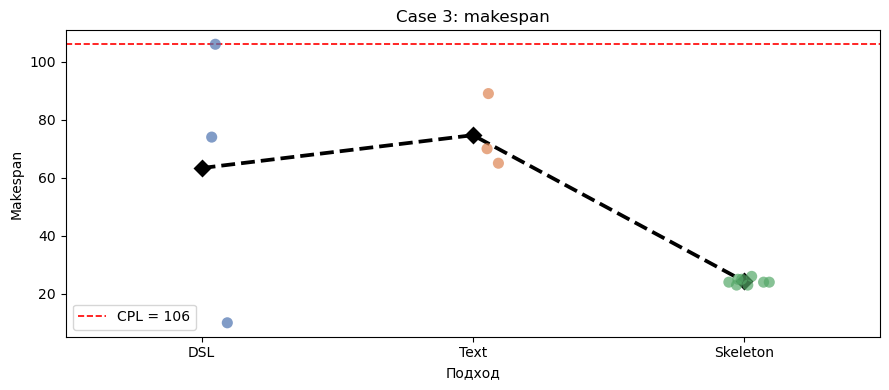

,count,mean,std,min,25%,50%,75%,max
Подход,,,,,,,,
DSL,3.0,63.3,48.9,10.0,42.0,74.0,90.0,106.0
Skeleton,8.0,24.2,1.0,23.0,23.8,24.0,25.0,26.0
Text,3.0,74.7,12.7,65.0,67.5,70.0,79.5,89.0


In [13]:
case = 'Case 3 (RCPSP+NRR)'
d3 = df_ok[df_ok['Кейс'] == case]

fig, ax = plt.subplots(figsize=(9, 4))
sns.stripplot(data=d3, x='Подход', y='Objective', order=['DSL','Text','Skeleton'],
              palette=colors, size=8, jitter=True, ax=ax, alpha=0.7)
sns.pointplot(data=d3, x='Подход', y='Objective', order=['DSL','Text','Skeleton'],
              color='black', markers='D', linestyles='--', ax=ax, errorbar=None)
ax.axhline(LOWER_BOUNDS[case], color='red', linestyle='--', linewidth=1.2,
           label=f'CPL = {LOWER_BOUNDS[case]}')
ax.set_title('Case 3: makespan')
ax.set_ylabel('Makespan')
ax.legend()
plt.tight_layout()
plt.show()

d3.groupby('Подход')['Objective'].describe().round(1)

Skeleton значительно превосходит DSL и Text: среднее 24.2 при стандартном отклонении 1.0 против 63.3/48.9 и 74.7/12.7. Все 8 успешных запусков Skeleton сосредоточены в узком диапазоне от 23 до 26, то есть результат стабилен и воспроизводим.

CPL = 106 здесь не является ориентиром для сравнения, поскольку в задаче с conditional scheduling выполняется только часть работ — выбранная ветвь в каждой группе альтернатив. Реальный оптимум существенно меньше CPL полного графа, и значения 23–26 физически корректны.

DSL имеет высокий разброс (стандартное отклонение 48.9, диапазон от 10 до 106) при всего 3 успешных запусках — нестабильная генерация инфраструктурного кода для conditional scheduling. Text аналогично показывает лишь 3 успешных запуска со средним 74.7.

### Case 4 Условный RCPSP

Целевая метрика: минимизация makespan.

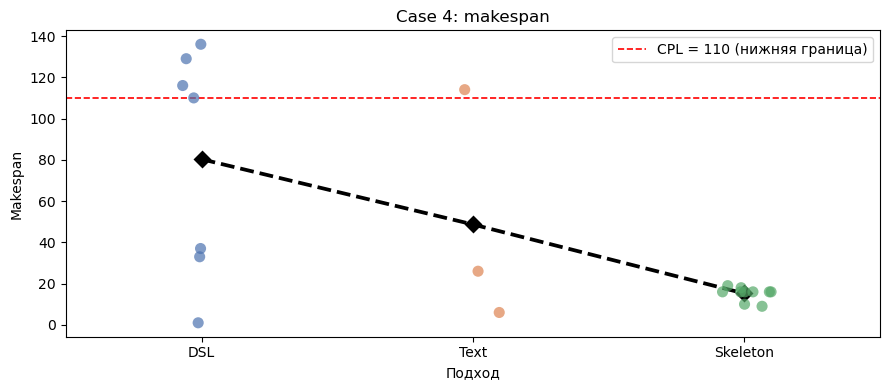

,count,mean,std,min,25%,50%,75%,max
Подход,,,,,,,,
DSL,7.0,80.3,54.8,1.0,35.0,110.0,122.5,136.0
Skeleton,10.0,15.2,3.2,9.0,16.0,16.0,16.0,19.0
Text,3.0,48.7,57.5,6.0,16.0,26.0,70.0,114.0


In [14]:
case = 'Case 4 (Conditional RCPSP)'
d4 = df_ok[df_ok['Кейс'] == case]

fig, ax = plt.subplots(figsize=(9, 4))
sns.stripplot(data=d4, x='Подход', y='Objective', order=['DSL','Text','Skeleton'],
              palette=colors, size=8, jitter=True, ax=ax, alpha=0.7)
sns.pointplot(data=d4, x='Подход', y='Objective', order=['DSL','Text','Skeleton'],
              color='black', markers='D', linestyles='--', ax=ax, errorbar=None)
ax.axhline(LOWER_BOUNDS[case], color='red', linestyle='--', linewidth=1.2,
           label=f'CPL = {LOWER_BOUNDS[case]} (нижняя граница)')
ax.set_title('Case 4: makespan')
ax.set_ylabel('Makespan')
ax.legend()
plt.tight_layout()
plt.show()

d4.groupby('Подход')['Objective'].describe().round(1)

Skeleton показывает наилучший результат: среднее 15.2 при стандартном отклонении 3.2, все 10 запусков в узком диапазоне от 9 до 19. DSL и Text имеют значительно больший разброс (стандартное отклонение 54.8 и 57.5) и только 7 и 3 успешных запуска соответственно.

CPL = 110 — это нижняя граница для полного графа без ресурсов, но как и в Case 3, conditional scheduling означает что выполняется только выбранная ветвь альтернатив, поэтому реальный оптимум существенно ниже. Несколько точек DSL и одна точка Text превышают CPL, что указывает на некорректную обработку selection groups в сгенерированном коде, алгоритм планирует избыточные ветви вместо выбора одной.

### Case 5 Многопроектный RCPSP

Целевая метрика: минимизация суммарного makespan всех проектов

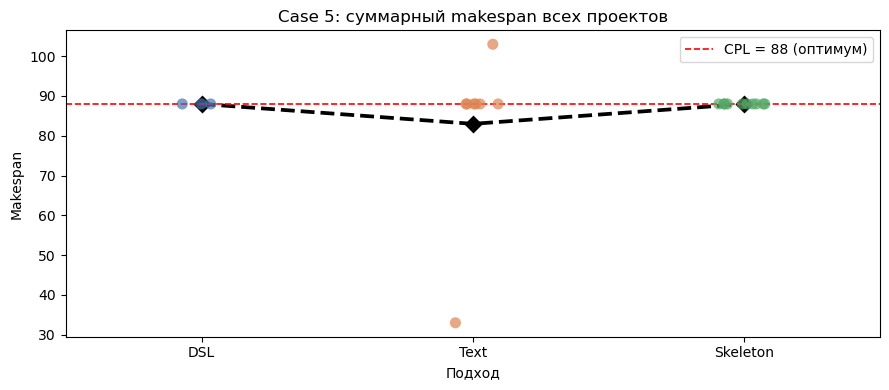

,count,mean,std,min,25%,50%,75%,max
Подход,,,,,,,,
DSL,3.0,88.0,0.0,88.0,88.0,88.0,88.0,88.0
Skeleton,10.0,88.0,0.0,88.0,88.0,88.0,88.0,88.0
Text,8.0,83.0,20.9,33.0,88.0,88.0,88.0,103.0


In [15]:
case = 'Case 5 (RCMPSP)'
d5 = df_ok[df_ok['Кейс'] == case]

fig, ax = plt.subplots(figsize=(9, 4))
sns.stripplot(data=d5, x='Подход', y='Objective', order=['DSL','Text','Skeleton'],
              palette=colors, size=8, jitter=True, ax=ax, alpha=0.7)
sns.pointplot(data=d5, x='Подход', y='Objective', order=['DSL','Text','Skeleton'],
              color='black', markers='D', linestyles='--', ax=ax, errorbar=None)
ax.axhline(LOWER_BOUNDS[case], color='red', linestyle='--', linewidth=1.2,
           label=f'CPL = {LOWER_BOUNDS[case]} (оптимум)')
ax.set_title('Case 5: суммарный makespan всех проектов')
ax.set_ylabel('Makespan')
ax.legend()
plt.tight_layout()
plt.show()

d5.groupby('Подход')['Objective'].describe().round(1)

Все три подхода в большинстве успешных запусков достигают оптимума makespanи = 88, совпадающего с CPL обоих проектов. DSL и Skeleton показывают нулевой разброс. Text менее стабилен: среднее 83.0, два выброса (33 и 103) указывают на некорректное вычисление метрики в части запусков. Skeleton при этом единственный подход с count = 10, все запуски успешны и корректны, тогда как DSL имеет лишь 3 успешных запуска из-за ошибок и timeout.

## 7. Анализ генерируемых эвристик

Какие методы выбирает LLM для каждого кейса и подхода

In [16]:
df_methods = df_all[df_all['Статус'] == 'OK'][['Подход','Кейс','Метод']].copy()

for case in sorted(df_methods['Кейс'].unique()):
    print(f"\n{'='*60}")
    print(f"  {case}")
    print('='*60)
    for подход in ['DSL', 'Text', 'Skeleton']:
        methods = df_methods[(df_methods['Кейс']==case) & (df_methods['Подход']==подход)]['Метод'].tolist()
        print(f"\n  [{подход}]")
        for m in methods:
            print(f"    • {m[:100]}")


  Case 1 (RCPSP)

  [DSL]
    • Event-driven Serial Schedule Generation Scheme (SSGS) + Priority by criticality (remaining path leng
    • SSGS + Priority rule (Resource Pressure First) + earliest feasible start (precedence + renewable cap
    • Priority List Scheduling (Criticality-based) + Earliest Feasible Start via boundary candidate search
    • SSGS + критичность (минимальный slack) + earliest-feasible time shifting по renewable ресурсам
    • Priority List Scheduling with Criticality (Longest Path) and Earliest Feasible Start (resource-aware
    • SGS + приоритет по критичности (длины до стока) и earliest-feasible start с проверкой по renewable c
    • Greedy event-based RCPSP list scheduling with criticality (backward longest-path) priority
    • SSGS + приоритет по критичности (remaining longest-path) с временным продвижением по ближайшему заве
    • Serial SGS + priority (min slack / criticality) + lookahead on earliest feasible start

  [Text]
    • SSGS с динамическим прио

Во всех пяти кейсах LLM двигается в сторону **жадных конструктивных алгоритмов (Greedy Constructive Heuristics)**, базирующихся на **List Scheduling (Schedule Generation Schemes - SGS)**, в сочетании с **правилами приоритизации (Priority Rules)** и **локальным поиском (Local Search)**. LLM отлично понимает классический арсенал исследования операций.

Но между подходами есть фундаментальная разница в **стиле выбора методов**:
*   **Text** склонен к «креативности» и добавлению метаэвристик (GRASP, Multi-start, Beam search).
*   **DSL** генерирует наиболее академичные и классические названия алгоритмов из литературы по OR.
*   **Skeleton** фокусируется на **детерминированной логике, точном распределении ресурсов (exact allocation) и правилах разрешения коллизий (tie-breaking)**, избегая сложных метаэвристик.

---

Разбор по Кейсам

* **Case 1 Классическая задача календарного планирования**

**DSL и Text:** Абсолютный консенсус вокруг **Serial SGS (SSGS)** с приоритетом по **критическому пути (Criticality / Longest remaining path)** и сдвигом на **ранний допустимый момент (Earliest Feasible Start)**. Text добавляет локальные улучшения (Left-Shifting).

**Skeleton:** Смещает фокус с названия схемы на **механизм распределения**. Вместо просто "SSGS" используется "exact renewable resource allocation". Приоритеты выбираются через жесткие tie-breakers (длительность, дефицит ресурсов).

Skeleton не придумывает сложные схемы, а детально прописывает, как именно разрешать коллизии при выборе_job'а, что делает код более устойчивым.

* **Case 2 Один прибор, общий директивный срок**

**DSL и Text:** Жадное построение (Greedy insertion/construction) с оценкой маржинального штрафа + **локальный поиск перестановками (adjacent/pairwise swaps)**. Text часто добавляет Multi-start и GRASP.

**Skeleton:** Отказывается от сложного локального поиска. Фокусируется на **EDD (Earliest Due Date)** и **SPT (Shortest Processing Time)** с модификациями под штраф (JIT-варианты). Выбирает минимизацию *немедленного* штрафа (one-step lookahead).

Skeleton упрощает задачу до быстрого жадного правила, что объясняет ее высокую надежность. Алгоритм детерминирован и не зависит от случайных стартов.

* **Case 3 Невозобновляемые ресурсы + Группы выбора**

**Text:** Пытается решить комбинаторный взрыв через **GRASP (Greedy Randomized Adaptive Search Procedure)** и **Beam Search**. LLM понимает, что жадный алгоритм здесь застрянет, и добавляет рандомизацию.

**DSL:** Добавляет проверки NRR-бюджета (budget-feasible) и штрафы за нехватку ресурсов (Resource Pressure) в стандартный SSGS.

**Skeleton:** Вводит концепцию **"Non-renewable scarcity pressure"** (давление дефицита невозобновляемых ресурсов). Вместо рандомизации (как в Text) Skeleton использует дефицит ресурсов как жесткий приоритет (tie-breaker) при выборе работ.

Text пытается обойти сложность метаэвристикой, а Skeleton встроить сложность в функцию приоритета.

* **Case 4 Условные приоритеты / OR-узлы**

**DSL и Text:** Используют **Event-driven scheduling** с **on-the-fly selection (выбором на лету)**. Когда алгоритм доходит до OR-узла, он жадно выбирает ветку на основе критичности или доступности ресурсов.

**Skeleton:** Использует более строгий подход — **"Selection-Group Decisiveness / Tightness"**. Алгоритм оценивает не просто критичность, а то, насколько «узким» или критичным является выбор группы. Фокус на "exact resource allocation" для выбранной ветки.

Skeleton формализует сам момент принятия решения (выбор группы), превращая его в часть функции приоритета, тогда как DSL/Text описывают это как процессный шаг ("on-the-fly commitment").

* **Case 5 Мульти-проектное планирование**

**DSL и Text:** Рассматривают задачу как один большой RCPSP. Используют **Global Priority-List** и **CPL (Critical Path Length) / Upward Rank** для всех проектов одновременно.

**Skeleton:** Делает упор на **Global Resource Pressure** (глобальное давление на ресурсы). Приоритет отдается работам, которые используют наиболее дефицитные глобальные ресурсы.

В мульти-проектных задачах Skeleton интуитивно выбирает стратегию "сглаживания пиков потребления ресурсов" (resource leveling) через приоритизацию, вместо простого следования критическому пути.

---

**Skeleton заставляет LLM мыслить как инженера-программиста, а не как исследователя.** 
Когда LLM просит написать текст эвристики (Text), он тянется к сложным методам из статей (GRASP), которые трудно корректно реализовать в рамках лимита токенов, что ведет к ошибкам и обрезке кода (низкая надежность). 

Когда LLM работает в рамках Skeleton, он понимает, что ему нужно заполнить тело функции `select_job` и `allocate`. Это заставляет его отбросить метаэвристики и сосредоточиться на **корректной проверке ограничений (feasibility checks)** и **правилах сортировки (priority/tie-breaking)**. Именно поэтому Skeleton генерирует меньше токенов, но работает стабильнее и надежнее.

# 8. Выводы

1. Skeleton - лучший по всем ключевым критериям

Skeleton показал наивысшую надежность (96%, 48/50) и лучшее качество решений. Для Cases 1 и 5 достигается оптимум (makespan 38 и 88) в 100% запусков. Для Cases 3 и 4 (conditional scheduling) Skeleton обеспечивает стабильный результат в узком диапазоне при нулевом или минимальном разбросе — в то время как DSL и Text дают широкий разброс и меньшее число успешных запусков.

2. DSL надежнее Text, но уступает Skeleton по качеству

DSL стабильно работает во всех кейсах (80-90% надежности) без критических провалов, тогда как Text показывает проблемы для Case 4 (60%). По качеству решений DSL и Text сопоставимы, но оба уступают Skeleton, особенно для Cases 3 и 4, где инфраструктурный код планировщика генерируется нестабильно.

3. Case 2 — системная проблема для DSL и Text

DSL и Text вычисляют метрику некорректно (значения ниже физически возможного минимума V-shape 92 760), тогда как Skeleton благодаря каркасу возвращает физически достоверные значения 56710–93762.

4. Архитектурное преимущество Skeleton

Разделение ответственности между каркасом и LLM решает три проблемы одновременно: устраняет бесконечные циклы (0 timeout у Skeleton), обеспечивает корректное вычисление целевой функции, и снижает вероятность ошибок интерпретации формата данных. Это позволяет модели сосредоточиться исключительно на логике выбора эвристики.